In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist

print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.2


In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [3]:
data = pd.read_csv("data_bt_dem.csv").dropna()
data=data[(data['draws']>1)]
participantcode = data.participant.unique()

data["draws"] = data["draws"].astype(theano.config.floatX)

In [4]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}
m_dtd=data["draws"].mean()
sd_dtd=data["draws"].std()

median_dtd=data["draws"].median()


In [5]:
hr_bt_pdi= pm.Model(coords=coords) 

with hr_bt_pdi:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=m_dtd, sigma=0.5)
    sigma_a = pm.HalfNormal("sigma_a", sd_dtd)
    mu_b = pm.Normal("mu_b", mu=0.0, sigma=0.5)
    sigma_b = pm.HalfNormal("sigma_b", 0.5)
    mu_b_pdi = pm.Normal("mu_b_pdi", mu=0.0, sigma=0.5)
    sigma_b_pdi = pm.HalfNormal("sigma_b_pdi", 0.5)
    

    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect difference  
    b = pm.Normal("b", mu=mu_b, sigma=sigma_b, dims="participant")
    b_pdi = pm.Normal("b_pdi", mu=mu_b_pdi, sigma=sigma_b_pdi, dims="participant")

    # Model error
    eps = pm.HalfCauchy("eps", 5.0)

    draws_est_pdi = a[participant_idx] + b[participant_idx] * data.session.values+ b_pdi[participant_idx] * data.pdi.values

    # Data likelihood
    draws_like_pdi = pm.Normal(
        "draws_like_pdi", mu=draws_est_pdi, sigma=eps, observed=data.draws, dims="obs_id"
    )
    
    

In [6]:
with hr_bt_pdi:
    hr_bt_trace_pdi = pm.sample(5000,tune=5000, target_accept=0.99, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eps, b_pdi, b, a, sigma_b_pdi, mu_b_pdi, sigma_b, mu_b, sigma_a, mu_a]


Sampling 2 chains for 5_000 tune and 5_000 draw iterations (10_000 + 10_000 draws total) took 1716 seconds.
There were 15 divergences after tuning. Increase `target_accept` or reparameterize.
There were 24 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.05 for some parameters. This indicates slight problems during sampling.
The estimated number of effective samples is smaller than 200 for some parameters.


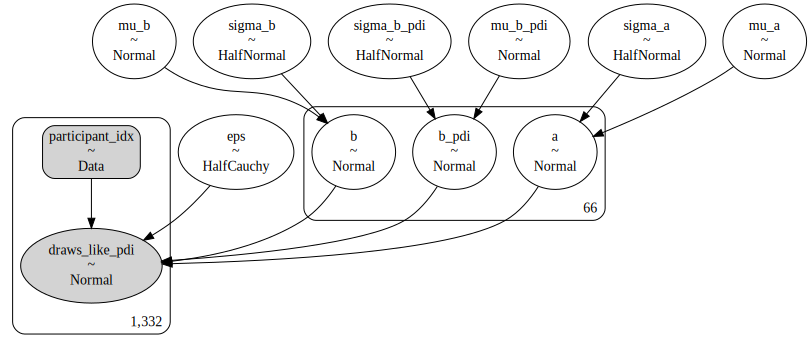

In [7]:
pm.model_to_graphviz(hr_bt_pdi)

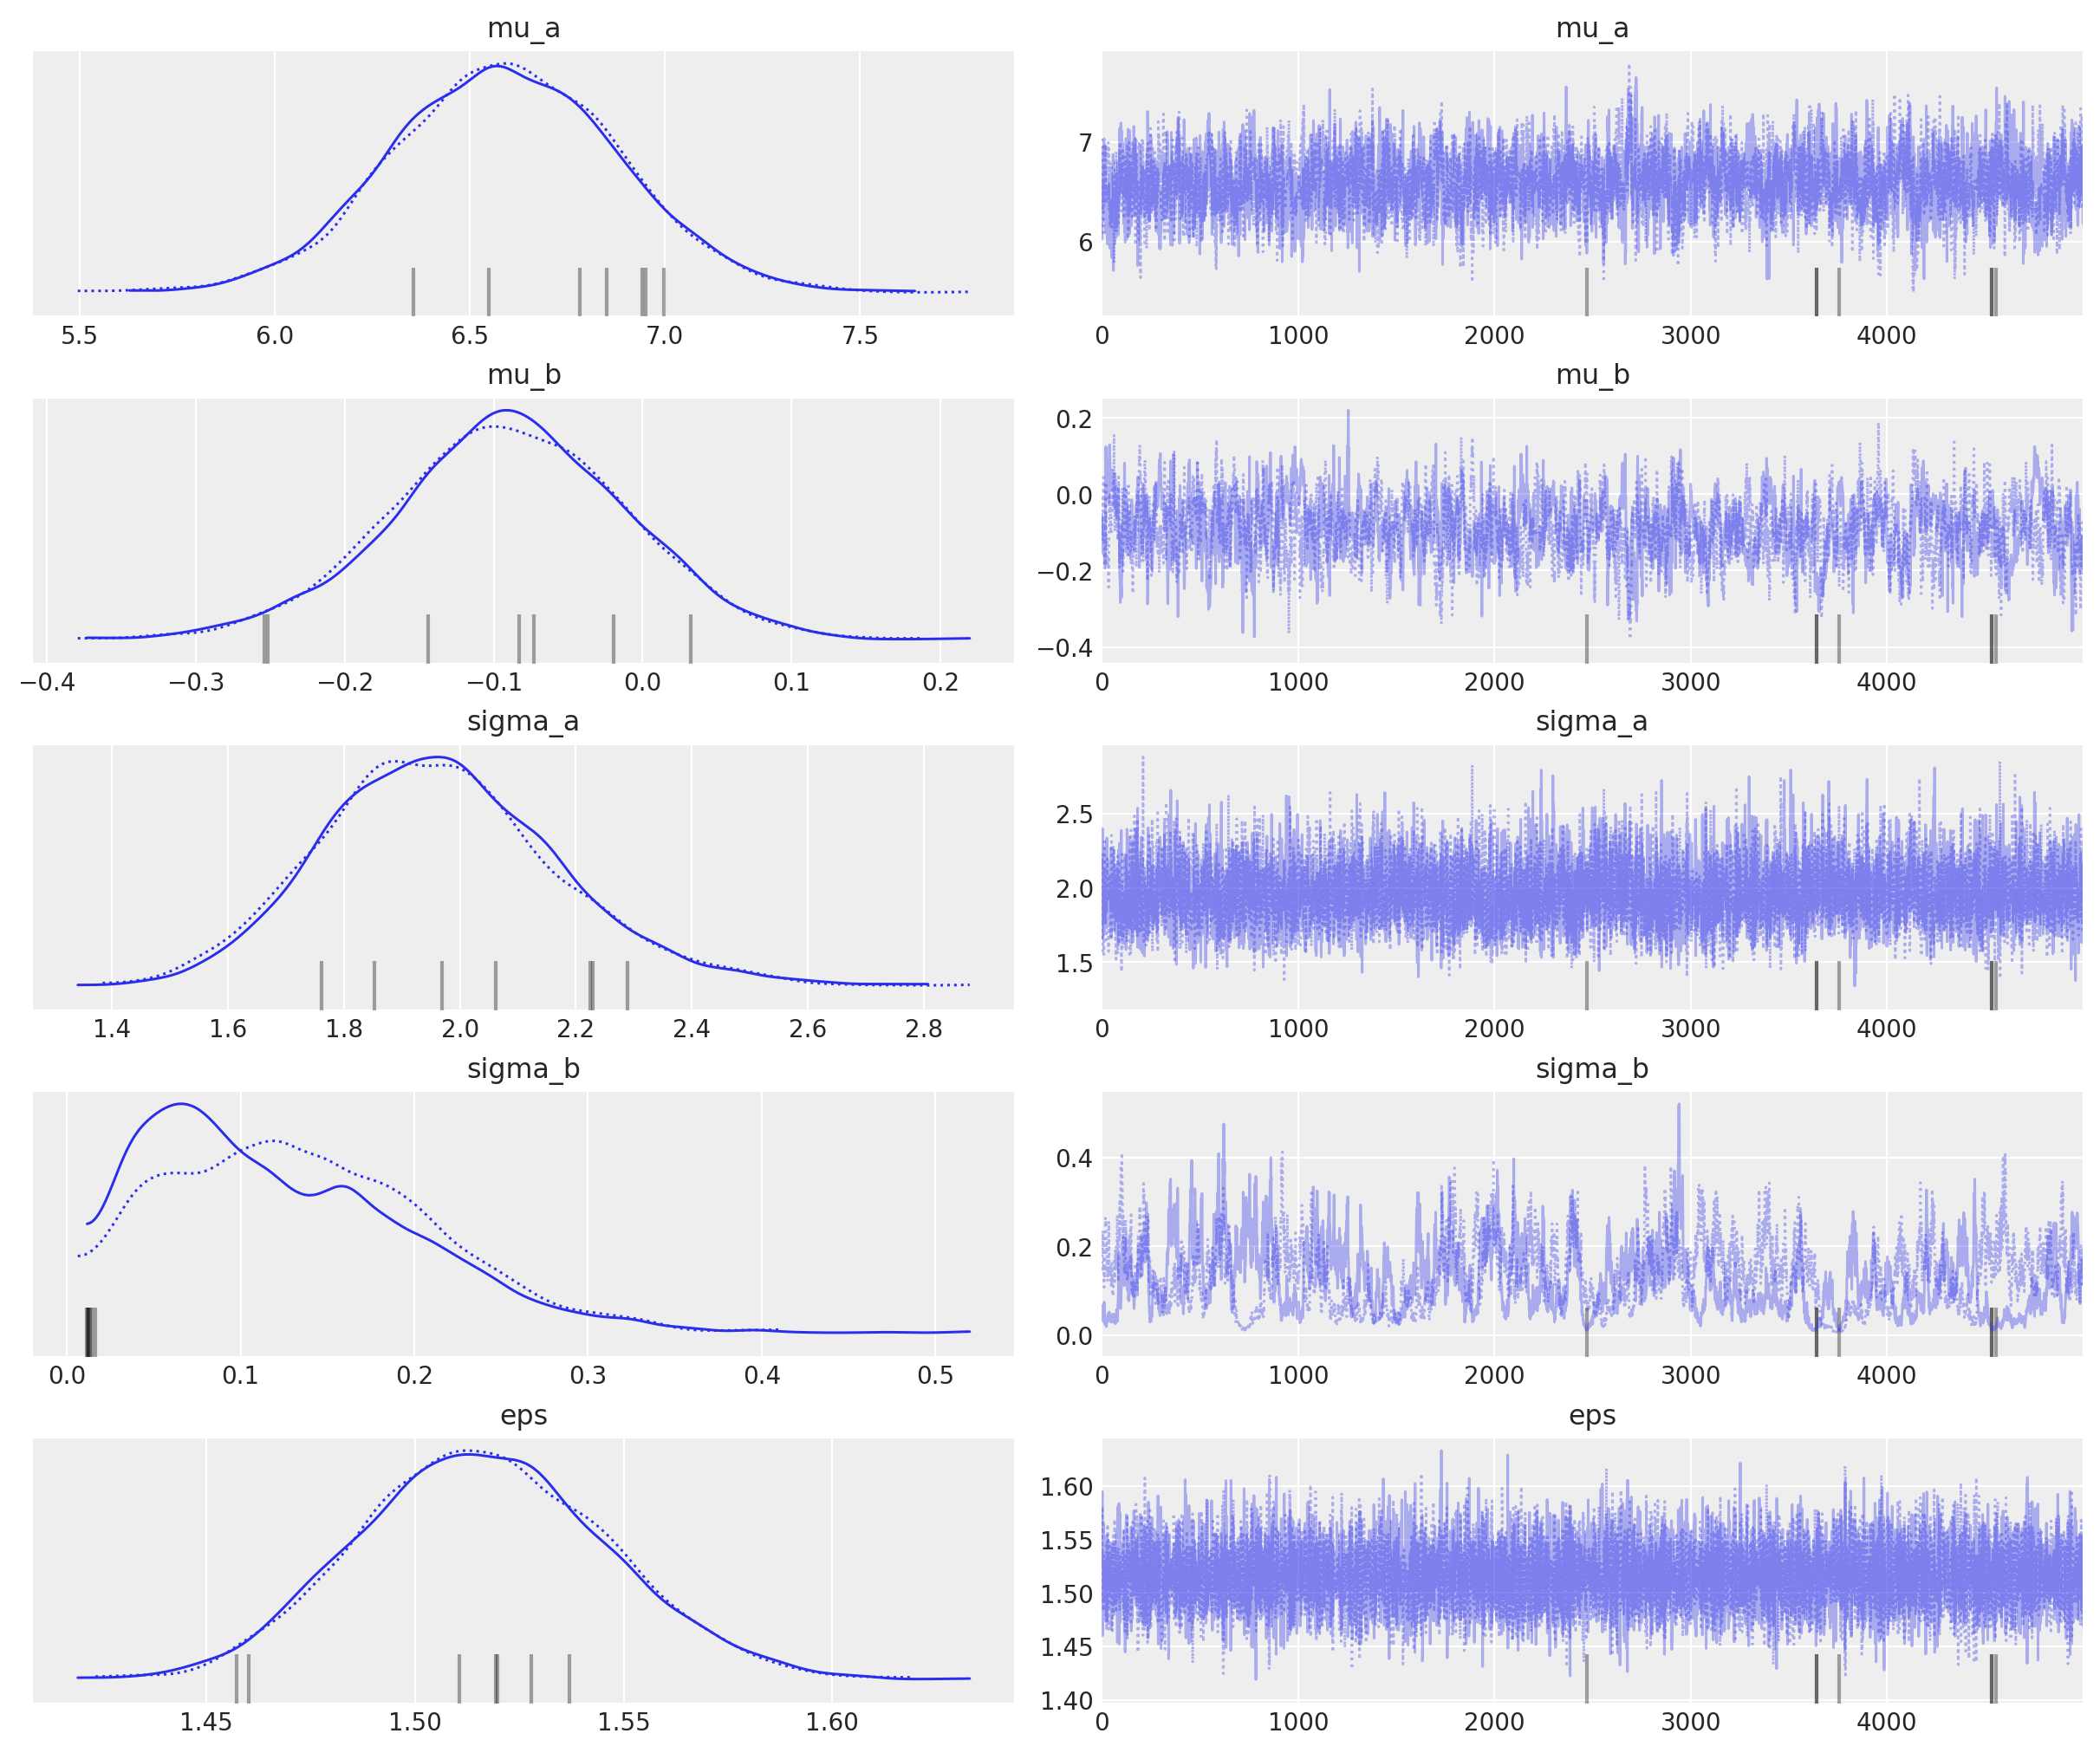

In [28]:
az.plot_trace(hr_bt_trace_pdi, var_names=["mu_a", "mu_b","mu_b_pdi",  "sigma_a", "sigma_b", "sigma_b_pdi","eps"]);

In [8]:
stat_tms_reg_pdi=pm.summary(hr_bt_trace_pdi)
stat_tms_reg_pdi


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,6.507,0.318,5.920,7.116,0.010,0.007,1037.0,1851.0,1.00
mu_b,-0.402,0.324,-1.029,0.172,0.016,0.011,431.0,697.0,1.00
mu_b_pdi,0.001,0.004,-0.007,0.010,0.000,0.000,740.0,1521.0,1.00
a[AD20],4.949,0.809,3.404,6.477,0.020,0.014,1557.0,2995.0,1.00
a[AF12],7.997,0.990,6.010,9.704,0.026,0.018,1477.0,3828.0,1.00
...,...,...,...,...,...,...,...,...,...
b_pdi[ZZ99],0.002,0.009,-0.016,0.019,0.000,0.000,2450.0,2589.0,1.00
sigma_a,1.887,0.199,1.502,2.248,0.006,0.004,1062.0,3286.0,1.00
sigma_b,0.346,0.269,0.016,0.822,0.051,0.036,20.0,29.0,1.13
sigma_b_pdi,0.007,0.004,0.000,0.014,0.000,0.000,111.0,78.0,1.00


In [9]:
b_mu_reg=stat_tms_reg_pdi.loc['mu_b']['mean']
b_sigma_reg=stat_tms_reg_pdi.loc['mu_b']['sd']

b_mu_reg_pdi=stat_tms_reg_pdi.loc['mu_b_pdi']['mean']
b_sigma_reg_pdi=stat_tms_reg_pdi.loc['mu_b_pdi']['sd']

In [10]:
print ("Beta TMS =/0") 
b_tms=NormalDist(mu=b_mu_reg, sigma=b_sigma_reg).overlap(NormalDist(mu=0, sigma=b_sigma_reg))
print (b_tms)

print ("Beta PDI =/0") 
b_pdi=NormalDist(mu=b_mu_reg_pdi, sigma=b_sigma_reg_pdi).overlap(NormalDist(mu=0, sigma=b_sigma_reg_pdi))
print (b_pdi)

Beta TMS =/0
0.535013974966897
Beta PDI =/0
0.9005235503397743


In [32]:
with hr_bt_pdi:
    ppc_reg = pm.sample_posterior_predictive(
        hr_bt_trace_pdi, var_names=["a", "b",,"b_pdi","draws_like"]
    )

<AxesSubplot:xlabel='draws_like / draws_like'>

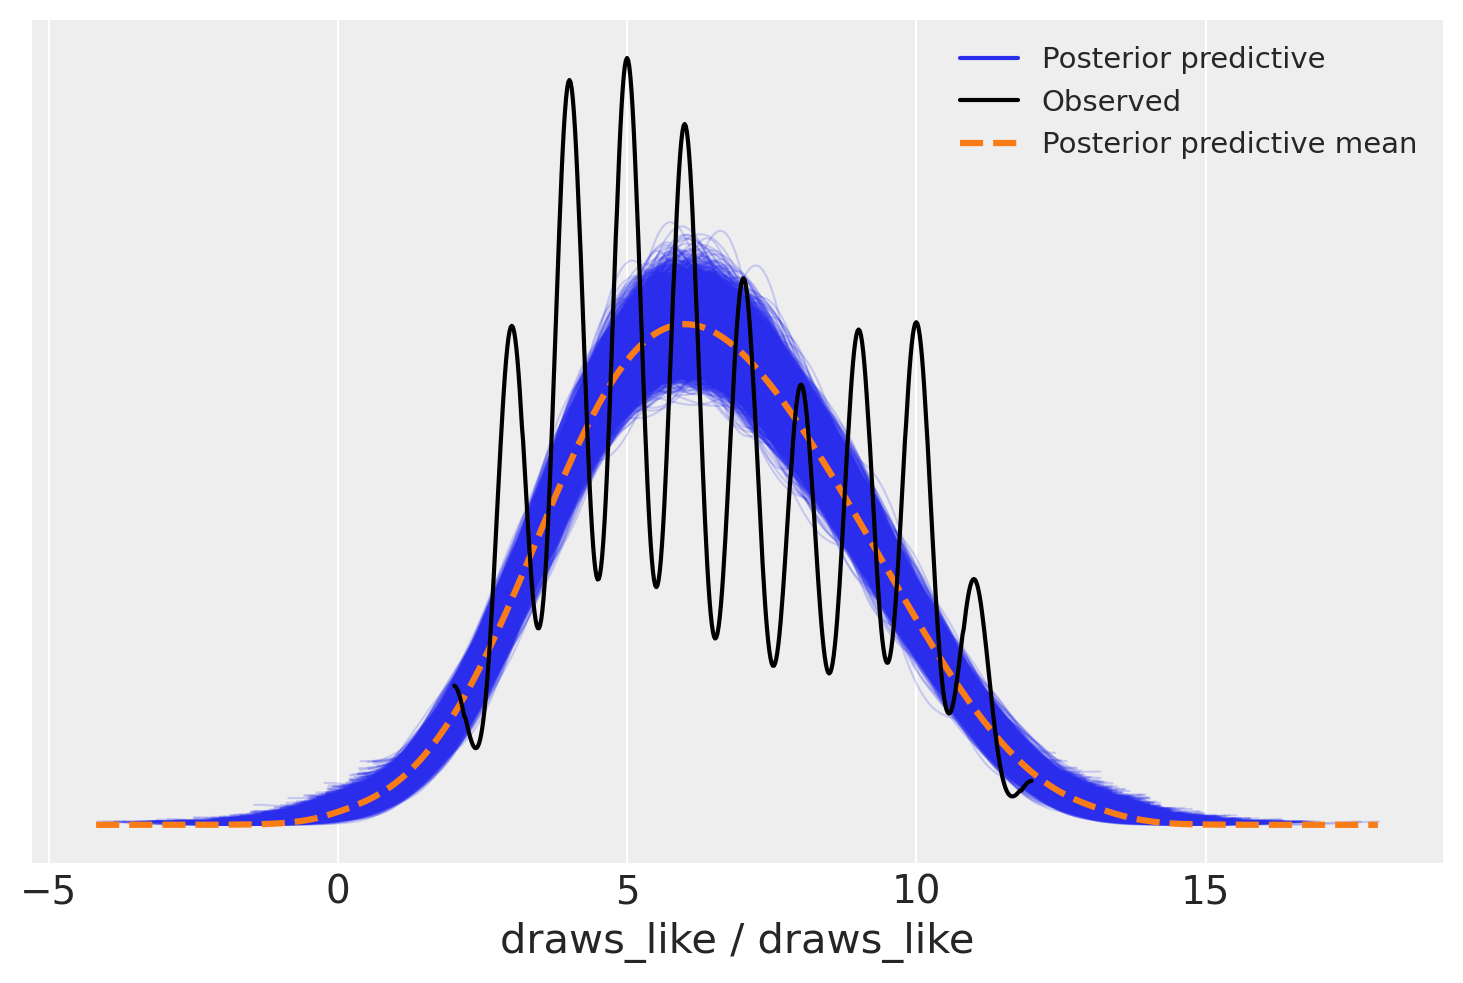

In [33]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hr_bt_pdi))

ValueError: not enough values to unpack (expected 2, got 1)

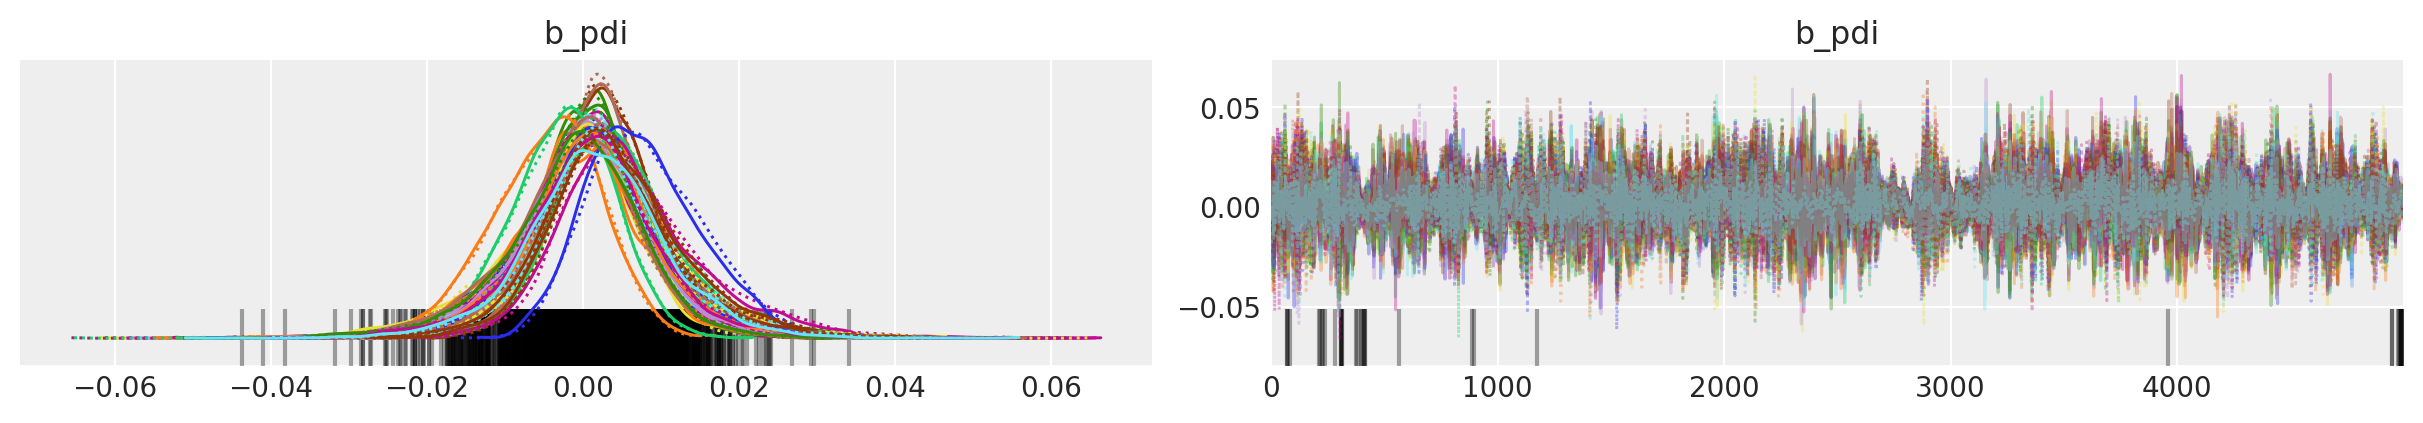

In [14]:
fig, b_trace_BT=az.plot_trace(hr_bt_trace_pdi, var_names=["b_pdi"], coords={"participant": participant});
